In [2]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from zhiyi.analysis.SE_analysis import get_site_index 
from scipy.spatial import cKDTree
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print("done")


done


In [3]:

SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"
filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_NOBB_month6/atm/hist/'
                 'MUSICA_production3.2_NOBB_month6.cam.h2.2018-MM-DD-03600.nc')

start_date = datetime.date(2018, 6, 16)
end_date   = datetime.date(2018, 6, 30)

city_lonlat = {
    'Manchester':[360 - 2.237881, 53.481520],
    'Liverpool':[360 - 2.844333, 53.346330],
    'Sheffield':[360 - 1.455815, 53.404950],
    'Birmingham':[360 - 1.874978, 52.476145],

}

In [4]:

def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = (template
             .replace("MM", cur.strftime("%m"))
             .replace("DD", cur.strftime("%d")))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        cur += datetime.timedelta(days=1)
    return files

def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce')
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=2):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['O3'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

scrip30 = xr.open_dataset(SCRIP_file)
scrip60 = xr.open_dataset(SCRIP_file_ne60)
se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)
ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")

Datasets loaded!


In [5]:

Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )
    Index_lonlat_60[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file_ne60
    )
TS     = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city]     = ds_ne30['O3'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['PM25'].values[:, -1, idx60] * 1e9

time_values      = pd.to_datetime(ds_ne30.time.values)
time_values_nobb = pd.to_datetime(ds_ne60.time.values)
tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

pm_min_30   = {}
pm_max_30   = {}
pm_min_60   = {}
pm_max_60   = {}
for city, (lon_c, lat_c) in city_lonlat.items():
    mn30, mx30 = get_3x3_minmax(
        ds_ne30, tree_30, lon180_30, lon_c, lat_c, k=9)
    mn60, mx60 = get_3x3_minmax(
        ds_ne60, tree_60, lon180_60, lon_c, lat_c, k=2)
    pm_min_30[city], pm_max_30[city] = mn30, mx30
    pm_min_60[city], pm_max_60[city] = mn60, mx60


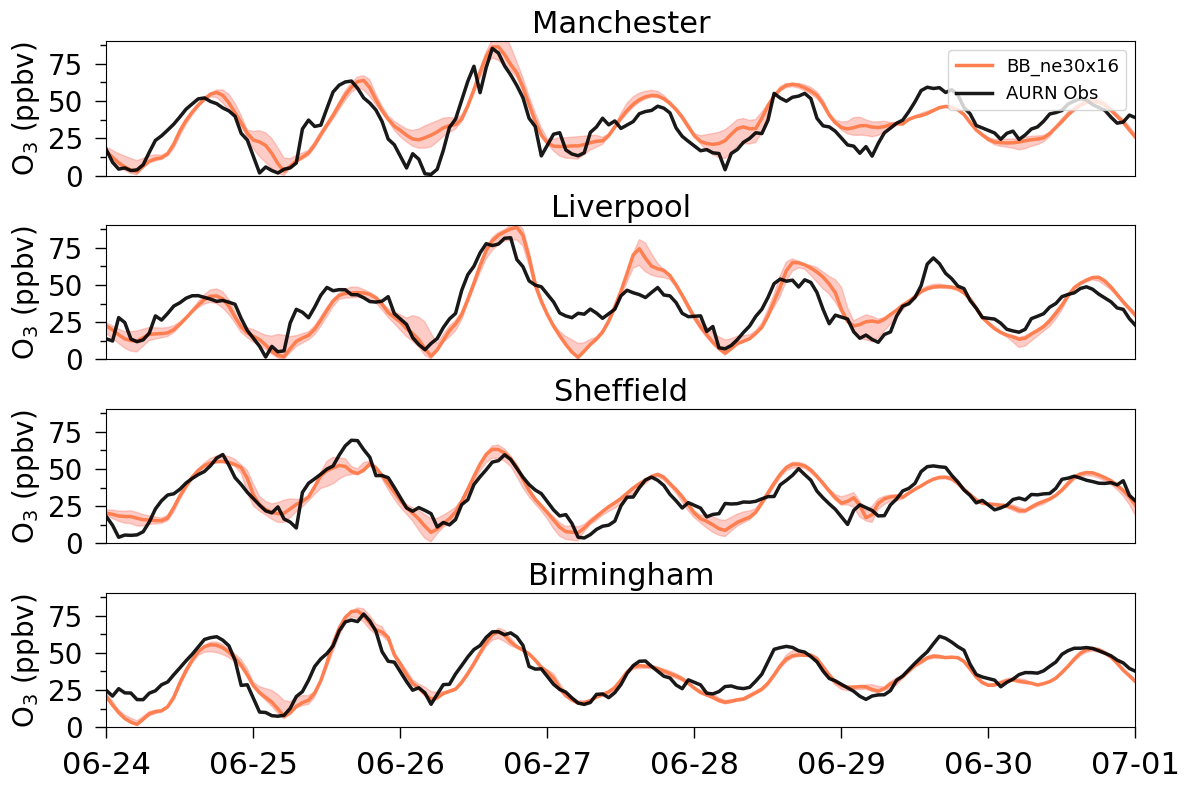

In [10]:
cities = list(city_lonlat.keys())
OBS_FILES = {
    "Manchester": "/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P3_o3/manchester_o3.csv",
    "Liverpool": "/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P3_o3/liverpool_o3.csv",
    "Sheffield": "/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P3_o3/sheffield_o3.csv",
    "Birmingham": "/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P3_o3/birmingham_o3.csv",
}
OBS_SCALE = {
    "Manchester": 0.5,
    "Liverpool": 0.495,
    "Sheffield": 0.4946,
    "Birmingham": 0.494,
}
OBS_START_DATE = pd.to_datetime("2018-06-01")
OBS_END_DATE = pd.to_datetime("2018-07-30")
PLOT_START_DATE = pd.to_datetime("2018-06-24")
PLOT_END_DATE = pd.to_datetime("2018-07-01")
FIRE_START_DATE = pd.to_datetime("2018-05-27")
FIRE_END_DATE = pd.to_datetime("2018-06-02")


def load_figure_s18_obs_data(obs_files=OBS_FILES, obs_scale=OBS_SCALE):
    obs_data = {}
    for city, obs_file in obs_files.items():
        obs_df = pd.read_csv(obs_file)
        obs_df["Date"] = pd.to_datetime(
            obs_df["Date"].astype(str) + " " + obs_df["Time"].astype(str),
            errors="coerce",
        )
        obs_sel = obs_df[(obs_df["Date"] >= OBS_START_DATE) & (obs_df["Date"] <= OBS_END_DATE)].sort_values("Date")
        obs_data[city] = pd.DataFrame(
            {
                "Date": obs_sel["Date"].values,
                "O3_obs": pd.to_numeric(obs_sel["average"], errors="coerce").values * obs_scale[city],
            }
        )
    return obs_data


def build_figure_s18_plot_data(cities, time_values, TS, pm_min_30, pm_max_30, obs_data):
    time_values_bst = (
        pd.to_datetime(time_values.astype("datetime64[ns]"))
        .tz_localize("UTC")
        .tz_convert("Europe/London")
        .tz_localize(None)
    )
    model_o3 = np.asarray([np.asarray(TS[city]).squeeze() for city in cities], dtype=float)
    model_o3_min = np.asarray([np.asarray(pm_min_30[city]).squeeze() for city in cities], dtype=float)
    model_o3_max = np.asarray([np.asarray(pm_max_30[city]).squeeze() for city in cities], dtype=float)

    obs_times = pd.DatetimeIndex([])
    for city in cities:
        obs_times = obs_times.union(pd.DatetimeIndex(obs_data[city]["Date"]))
    obs_o3 = np.full((len(cities), len(obs_times)), np.nan, dtype=float)
    for i, city in enumerate(cities):
        obs_series = pd.Series(obs_data[city]["O3_obs"].values, index=pd.DatetimeIndex(obs_data[city]["Date"]))
        obs_o3[i, :] = obs_series.reindex(obs_times).values

    return {
        "cities": cities,
        "model_time": pd.DatetimeIndex(time_values_bst),
        "model_o3": model_o3,
        "model_o3_min": model_o3_min,
        "model_o3_max": model_o3_max,
        "obs_time": obs_times,
        "obs_o3": obs_o3,
    }


def plot_figure_s18(plot_data):
    cities = plot_data["cities"]
    model_time = plot_data["model_time"]
    model_o3 = plot_data["model_o3"]
    model_o3_min = plot_data["model_o3_min"]
    model_o3_max = plot_data["model_o3_max"]
    obs_time = plot_data["obs_time"]
    obs_o3 = plot_data["obs_o3"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 8))
    day_locator = mdates.DayLocator(interval=1)
    day_formatter = mdates.DateFormatter("%m-%d")

    for i, city in enumerate(cities):
        ax = axes[i]
        ax.fill_between(model_time, model_o3_min[i], model_o3_max[i], alpha=0.4, color="salmon")
        ax.plot(model_time, model_o3[i], color="coral", linewidth=2.5, label="BB_ne30x16")
        ax.axvspan(FIRE_START_DATE, FIRE_END_DATE, color="green", alpha=0.15, zorder=0)
        ax.plot(obs_time, obs_o3[i], color="black", linewidth=2.5, alpha=0.9, label="AURN Obs")

        ax.set_title(city, fontsize=22)
        ax.xaxis.set_major_locator(day_locator)
        ax.xaxis.set_major_formatter(day_formatter)
        ax.set_xlim(PLOT_START_DATE, PLOT_END_DATE)

        plt.setp(ax.get_yticklabels(), fontsize=20)
        if i in [0, 1, 2]:
            ax.tick_params(axis="x", which="both", labelbottom=False)
            ax.set_xticks([])
        else:
            plt.setp(ax.get_xticklabels(), rotation=0, fontsize=25)
            # ax.set_xlabel("Date", fontsize=18)
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
            ax.tick_params(axis="x", which="major", labelsize=22, pad=9, length=8, width=1)
            ax.tick_params(axis="x", which="minor", labelsize=18 * 0.8, length=4, width=1)

        ax.set_ylabel("O$_{3}$ (ppbv)", fontsize=20)
        ax.yaxis.set_major_locator(MultipleLocator(25))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.set_ylim(0, 90)
        ax.tick_params(axis="y", which="major", labelsize=20, pad=9, length=8, width=1)
        ax.tick_params(axis="y", which="minor", labelsize=18 * 0.8, length=4, width=1)
        axes[0].legend(fontsize=13, loc="upper right")
        ax.xaxis.set_major_formatter(day_formatter)

    plt.tight_layout(h_pad=0.1)
    return fig, axes


obs_data = load_figure_s18_obs_data()
figure_s18_plot_data = build_figure_s18_plot_data(cities, time_values, TS, pm_min_30, pm_max_30, obs_data)
fig, axes = plot_figure_s18(figure_s18_plot_data)


In [7]:
figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure_s18_nc = os.path.join(figure_data_dir, "FigureS18.nc")
os.makedirs(figure_data_dir, exist_ok=True)

figure_s18_data = xr.Dataset(
    data_vars={
        "model_o3": (("city", "model_time"), figure_s18_plot_data["model_o3"]),
        "model_o3_min": (("city", "model_time"), figure_s18_plot_data["model_o3_min"]),
        "model_o3_max": (("city", "model_time"), figure_s18_plot_data["model_o3_max"]),
        "obs_o3": (("city", "obs_time"), figure_s18_plot_data["obs_o3"]),
    },
    coords={
        "city": figure_s18_plot_data["cities"],
        "model_time": [pd.Timestamp(t).strftime("%Y-%m-%d %H:%M:%S") for t in figure_s18_plot_data["model_time"]],
        "obs_time": [pd.Timestamp(t).strftime("%Y-%m-%d %H:%M:%S") for t in figure_s18_plot_data["obs_time"]],
    },
    attrs={
        "description": "Figure S18 plotting data generated from original model and AURN O3 data",
        "model_unit": "ppbv",
        "obs_unit": "ppbv after station-specific conversion factor",
        "plot_start_date": PLOT_START_DATE.strftime("%Y-%m-%d"),
        "plot_end_date": PLOT_END_DATE.strftime("%Y-%m-%d"),
        "fire_start_date": FIRE_START_DATE.strftime("%Y-%m-%d"),
        "fire_end_date": FIRE_END_DATE.strftime("%Y-%m-%d"),
    },
)
figure_s18_data.to_netcdf(figure_s18_nc)
figure_s18_nc


'/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS18.nc'

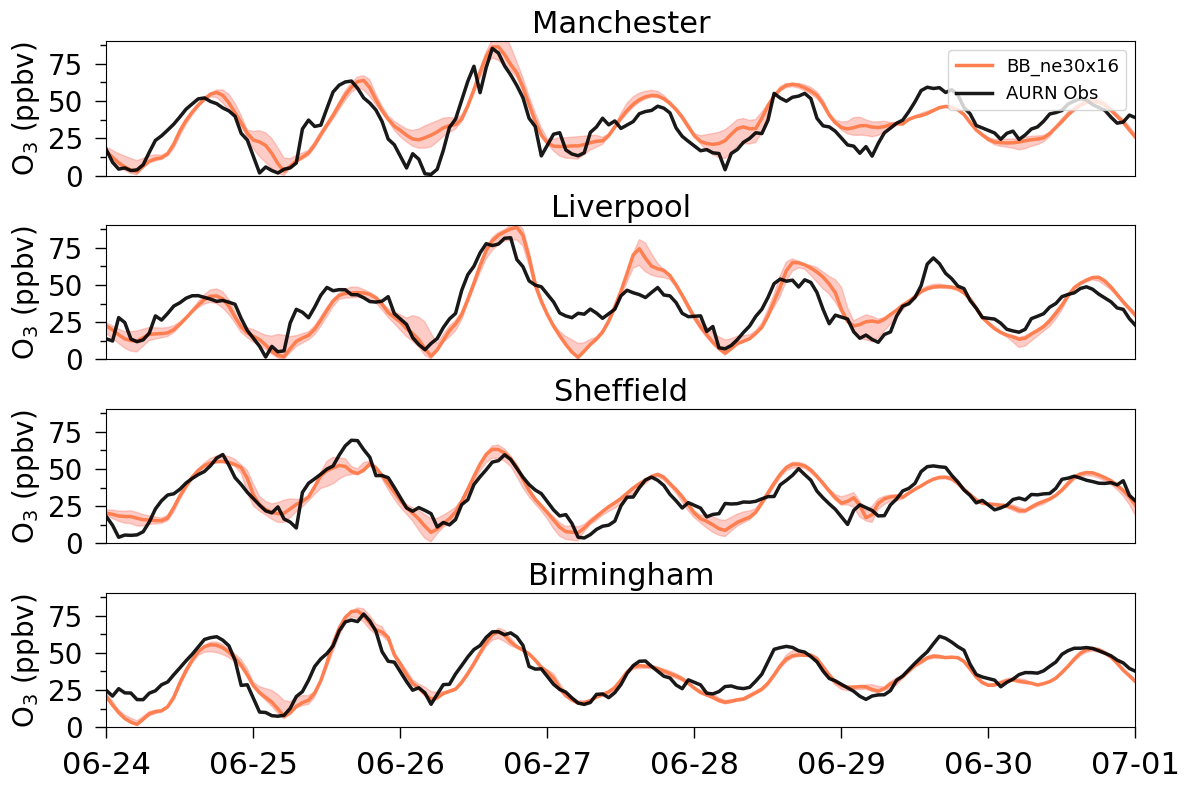

In [12]:
figure_s18_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS18.nc"
figure_s18_saved = xr.open_dataset(figure_s18_nc)

saved_cities = figure_s18_saved["city"].values.astype(str).tolist()
model_time_saved = pd.to_datetime(figure_s18_saved["model_time"].values)
obs_time_saved = pd.to_datetime(figure_s18_saved["obs_time"].values)
model_o3_saved = figure_s18_saved["model_o3"].values
model_o3_min_saved = figure_s18_saved["model_o3_min"].values
model_o3_max_saved = figure_s18_saved["model_o3_max"].values
obs_o3_saved = figure_s18_saved["obs_o3"].values

plot_start_date = pd.to_datetime(figure_s18_saved.attrs["plot_start_date"])
plot_end_date = pd.to_datetime(figure_s18_saved.attrs["plot_end_date"])
fire_start_date = pd.to_datetime(figure_s18_saved.attrs["fire_start_date"])
fire_end_date = pd.to_datetime(figure_s18_saved.attrs["fire_end_date"])

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
day_locator = mdates.DayLocator(interval=1)
day_formatter = mdates.DateFormatter("%m-%d")

for i, city in enumerate(saved_cities):
    ax = axes[i]
    ax.fill_between(
        model_time_saved,
        model_o3_min_saved[i],
        model_o3_max_saved[i],
        alpha=0.4,
        color="salmon",
    )
    ax.plot(
        model_time_saved,
        model_o3_saved[i],
        color="coral",
        linewidth=2.5,
        label="BB_ne30x16",
    )
    ax.axvspan(fire_start_date, fire_end_date, color="green", alpha=0.15, zorder=0)
    ax.plot(
        obs_time_saved,
        obs_o3_saved[i],
        color="black",
        linewidth=2.5,
        alpha=0.9,
        label="AURN Obs",
    )

    ax.set_title(city, fontsize=22)
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_formatter)
    ax.set_xlim(plot_start_date, plot_end_date)

    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis="x", which="both", labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=25)
        # ax.set_xlabel("Date", fontsize=18)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.tick_params(axis="x", which="major", labelsize=22, pad=9, length=8, width=1)
        ax.tick_params(axis="x", which="minor", labelsize=18 * 0.8, length=4, width=1)

    ax.set_ylabel("O$_{3}$ (ppbv)", fontsize=20)
    ax.yaxis.set_major_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_ylim(0, 90)
    ax.tick_params(axis="y", which="major", labelsize=20, pad=9, length=8, width=1)
    ax.tick_params(axis="y", which="minor", labelsize=18 * 0.8, length=4, width=1)
    axes[0].legend(fontsize=13, loc="upper right")
    ax.xaxis.set_major_formatter(day_formatter)

plt.tight_layout(h_pad=0.1)

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS18.png"
pdf_path = FIGURES_DIR / "FigureS18.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
figure_s18_saved.close()
